# **Project Title: Tallest People in the World Dataset Cleaning**

## **Dataset Overview**
The dataset is about the tallest people in the World, a comprehensive and meticulously curated record of over 150 of the world's tallest individuals, covering a vast historical timeline from the year 1600 to 2026.

* The dataset is provided at Kaggle.com, link is provided here 'https://www.kaggle.com/datasets/furkanbtk/tallest-people-in-the-world'

* The dataset contains the following columns; id, name, gender, country, continent, height_cm, height_ft_in, weight_kg, birth_year, death_year, lifespan, occupation, medical_condition, is_alive.

* The original dataset size is: 157 rows and 14 columns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df_tall_people = pd.read_csv('tallest_people_in_the_world.csv')

In [3]:
df_tall_people

,id,name,gender,country,continent,height_cm,height_ft_in,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
0,1,John F. Carroll,Male,USA,North America,264,8 ft 8 in,140.0,1932,1969.0,37,NaN,Acromegaly,0
1,2,Robert Wadlow,Male,USA,North America,272,8 ft 11 in,199.0,1918,1940.0,22,Entertainer,Gigantism,0
2,3,John Rogan,Male,USA,North America,267,8 ft 9 in,79.0,1868,1905.0,37,Seller,Gigantism,0
3,4,Willie Camper,Male,USA,North America,260,8 ft 6.3 in,170.0,1924,1943.0,18,Entertainer,Gigantism,0
4,5,Siah Khan,Male,Iran,Asia,259,8 ft 6 in,155.0,1913,1939.0,26,Entertainer,Gigantism,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,Jaana Kotova,Female,Estonia,Europe,210,6 ft 10.7 in,NaN,1964,NaN,62,Athlete,Genetic,1
153,154,Miranda Weber,Female,Canada,North America,211,6 ft 11 in,NaN,1982,NaN,44,Athlete,Genetic,1
154,155,Uljana Semjonova,Female,Latvia,Europe,213,7 ft 0 in,120.0,1952,NaN,74,Athlete,Genetic,1
155,156,Kristina Larsdotter,Female,Sweden,Europe,210,6 ft 10.7 in,NaN,1819,1854.0,35,Entertainer,Gigantism,0


## **Checking for null values, datatypes and then handling them**
* Checked for the data types and changed the death_year from float to int so that it is the same data type as the birth_year since they are both years
  
#### **Dealing with null values**
- For the missing occupations of the individuals in the "occupation" column, the word "Unknow" was filled for the missing occupations being that they are not known.
- For the missing years in death_year, the individuals are still alive so they dont have death_years that are registered as yet so that is left as "NaN"
- For the numerical missing values in the "weight" column, the median weight is filled because it is robust to outliers and represents the central tendency of the data well, whereby it is stable during other calculations in the dataset

In [4]:
#  checking for datatypes
df_tall_people.dtypes

id                     int64
name                  object
gender                object
country               object
continent             object
height_cm              int64
height_ft_in          object
weight_kg            float64
birth_year             int64
death_year           float64
lifespan               int64
occupation            object
medical_condition     object
is_alive               int64
dtype: object

In [5]:
df_tall_people.isnull().sum()

id                    0
name                  0
gender                0
country               0
continent             0
height_cm             0
height_ft_in          0
weight_kg            83
birth_year            0
death_year           73
lifespan              0
occupation           46
medical_condition     0
is_alive              0
dtype: int64

In [6]:
# Checking for how many are still alive and how many are dead
df_tall_people['is_alive'].value_counts()

is_alive
0    84
1    73
Name: count, dtype: int64

In [9]:
# converting the death year to integer
df_tall_people['death_year'] = df_tall_people['death_year'].astype('Int64')
df_tall_people

,id,name,gender,country,continent,height_cm,height_ft_in,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
0,1,John F. Carroll,Male,USA,North America,264,8 ft 8 in,140.0,1932,1969,37,NaN,Acromegaly,0
1,2,Robert Wadlow,Male,USA,North America,272,8 ft 11 in,199.0,1918,1940,22,Entertainer,Gigantism,0
2,3,John Rogan,Male,USA,North America,267,8 ft 9 in,79.0,1868,1905,37,Seller,Gigantism,0
3,4,Willie Camper,Male,USA,North America,260,8 ft 6.3 in,170.0,1924,1943,18,Entertainer,Gigantism,0
4,5,Siah Khan,Male,Iran,Asia,259,8 ft 6 in,155.0,1913,1939,26,Entertainer,Gigantism,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,Jaana Kotova,Female,Estonia,Europe,210,6 ft 10.7 in,NaN,1964,<NA>,62,Athlete,Genetic,1
153,154,Miranda Weber,Female,Canada,North America,211,6 ft 11 in,NaN,1982,<NA>,44,Athlete,Genetic,1
154,155,Uljana Semjonova,Female,Latvia,Europe,213,7 ft 0 in,120.0,1952,<NA>,74,Athlete,Genetic,1
155,156,Kristina Larsdotter,Female,Sweden,Europe,210,6 ft 10.7 in,NaN,1819,1854,35,Entertainer,Gigantism,0


In [10]:
# Check for the datatype again
df_tall_people.dtypes

id                     int64
name                  object
gender                object
country               object
continent             object
height_cm              int64
height_ft_in          object
weight_kg            float64
birth_year             int64
death_year             Int64
lifespan               int64
occupation            object
medical_condition     object
is_alive               int64
dtype: object

In [11]:
# fill in the null occupations with unknown
df_tall_people['occupation'] = df_tall_people['occupation'].fillna('Unknown')

In [12]:
# we use median because it stays stable, doesnt over hike the outliers in the dataset and also the middle value
median_weight = df_tall_people['weight_kg'].median()

In [13]:
# fill the null weights with the median value
df_tall_people['weight_kg'] = df_tall_people['weight_kg'].fillna(median_weight)

In [14]:
df_tall_people

,id,name,gender,country,continent,height_cm,height_ft_in,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
0,1,John F. Carroll,Male,USA,North America,264,8 ft 8 in,140.0,1932,1969,37,Unknown,Acromegaly,0
1,2,Robert Wadlow,Male,USA,North America,272,8 ft 11 in,199.0,1918,1940,22,Entertainer,Gigantism,0
2,3,John Rogan,Male,USA,North America,267,8 ft 9 in,79.0,1868,1905,37,Seller,Gigantism,0
3,4,Willie Camper,Male,USA,North America,260,8 ft 6.3 in,170.0,1924,1943,18,Entertainer,Gigantism,0
4,5,Siah Khan,Male,Iran,Asia,259,8 ft 6 in,155.0,1913,1939,26,Entertainer,Gigantism,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152,153,Jaana Kotova,Female,Estonia,Europe,210,6 ft 10.7 in,140.0,1964,<NA>,62,Athlete,Genetic,1
153,154,Miranda Weber,Female,Canada,North America,211,6 ft 11 in,140.0,1982,<NA>,44,Athlete,Genetic,1
154,155,Uljana Semjonova,Female,Latvia,Europe,213,7 ft 0 in,120.0,1952,<NA>,74,Athlete,Genetic,1
155,156,Kristina Larsdotter,Female,Sweden,Europe,210,6 ft 10.7 in,140.0,1819,1854,35,Entertainer,Gigantism,0


## **Dealing with the height**
We are given height in both feet and cms, i prefer keeping the height in cm because calculations are easy and more precise.
* Dropped the column in feet and kept the one in centimeters
* set the id column to be the index so that each individual is searched for according to his/her id

In [15]:
# drop the height in feet column to remain with the height in cms
df_tall_people.drop(columns=['height_ft_in'], inplace=True)

In [16]:
# set the id column as the index
df_tall_people.set_index('id', inplace=True)

In [17]:
df_tall_people

,name,gender,country,continent,height_cm,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
id,,,,,,,,,,,,
1,John F. Carroll,Male,USA,North America,264,140.0,1932,1969,37,Unknown,Acromegaly,0
2,Robert Wadlow,Male,USA,North America,272,199.0,1918,1940,22,Entertainer,Gigantism,0
3,John Rogan,Male,USA,North America,267,79.0,1868,1905,37,Seller,Gigantism,0
4,Willie Camper,Male,USA,North America,260,170.0,1924,1943,18,Entertainer,Gigantism,0
5,Siah Khan,Male,Iran,Asia,259,155.0,1913,1939,26,Entertainer,Gigantism,0
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Jaana Kotova,Female,Estonia,Europe,210,140.0,1964,<NA>,62,Athlete,Genetic,1
154,Miranda Weber,Female,Canada,North America,211,140.0,1982,<NA>,44,Athlete,Genetic,1
155,Uljana Semjonova,Female,Latvia,Europe,213,120.0,1952,<NA>,74,Athlete,Genetic,1


# Identifying outliers in numerical data

<Axes: ylabel='Frequency'>

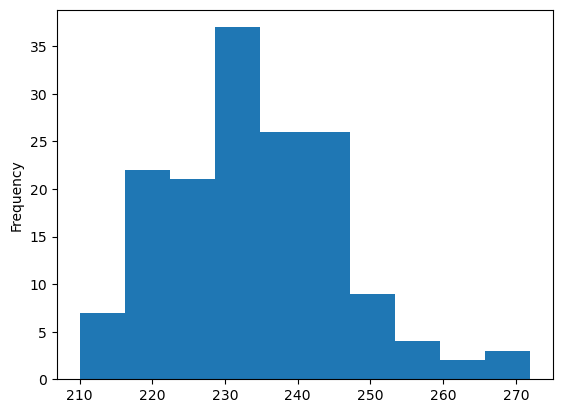

In [18]:
# histogram to know outliers in height  
df_tall_people['height_cm'].plot(kind='hist', bins=10)

#### The histogram presents a normal distribution with a few outliers

In [19]:
# get the bar ranges with value_counts method and number of the bins
df_tall_people['height_cm'].value_counts(bins=10).sort_index()

(209.93699999999998, 216.2]     7
(216.2, 222.4]                 22
(222.4, 228.6]                 21
(228.6, 234.8]                 37
(234.8, 241.0]                 31
(241.0, 247.2]                 21
(247.2, 253.4]                  9
(253.4, 259.6]                  4
(259.6, 265.8]                  2
(265.8, 272.0]                  3
Name: count, dtype: int64

**This shouldnt be confusing, I went ahead and got the values i calculated from the box plot (198.5 and 266.5) and used them in this example as well so that i can get the exact calculations for the values and get the exact outliers.**

In [20]:
# without the outliers
# here its values that are in the middle(that are in range including the 50th percentile)
df_tall_people[(df_tall_people['height_cm']>198.5) & (df_tall_people['height_cm']<266.5)]

,name,gender,country,continent,height_cm,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
id,,,,,,,,,,,,
1,John F. Carroll,Male,USA,North America,264,140.0,1932,1969,37,Unknown,Acromegaly,0
4,Willie Camper,Male,USA,North America,260,170.0,1924,1943,18,Entertainer,Gigantism,0
5,Siah Khan,Male,Iran,Asia,259,155.0,1913,1939,26,Entertainer,Gigantism,0
6,Akashi Shiganosuke,Male,Japan,Asia,254,185.0,1600,1649,49,Athlete,Gigantism,0
7,Vrolijk de Beers,Male,Malawi,Africa,246,130.0,1925,1961,36,Entertainer,Gigantism,0
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Jaana Kotova,Female,Estonia,Europe,210,140.0,1964,<NA>,62,Athlete,Genetic,1
154,Miranda Weber,Female,Canada,North America,211,140.0,1982,<NA>,44,Athlete,Genetic,1
155,Uljana Semjonova,Female,Latvia,Europe,213,120.0,1952,<NA>,74,Athlete,Genetic,1


In [21]:
# dealing with outliers(the outliers)
# here we determine values that are less than the min whisker and are also greater than the max whisker so that we can get the outliers
df_tall_people[~(df_tall_people['height_cm']<198.5) & (df_tall_people['height_cm']>266.5)]

,name,gender,country,continent,height_cm,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
id,,,,,,,,,,,,
2,Robert Wadlow,Male,USA,North America,272,199.0,1918,1940,22,Entertainer,Gigantism,0
3,John Rogan,Male,USA,North America,267,79.0,1868,1905,37,Seller,Gigantism,0
9,Pornchai Saosri,Male,Thailand,Asia,269,140.0,1989,2015,26,Unknown,Gigantism,0


<Axes: >

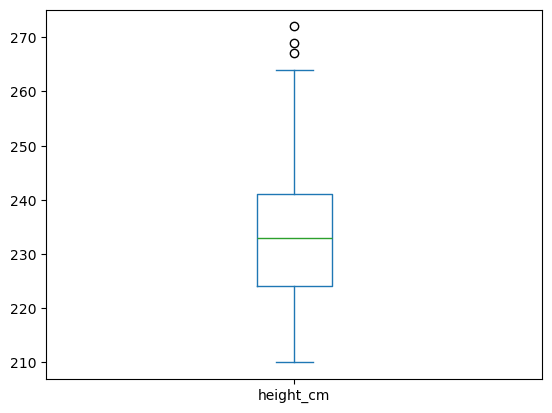

In [22]:
# using box plot for outliers(best for getting the outliers)
df_tall_people['height_cm'].plot(kind='box')

- The data is skewed
- It is mildly skewed to the right (it is a positive skew)
- can be a negative skew if the line below Q1(25th percentile) is longer than the one above Q3(75th percentile)
- There are three high value outliers 

#### **Explaining the data**
* Most data is fairly balanced but slightly centered toward the lower values. The median is little closer to the lower quartile, and the upper whisker stretches further than the lower whisker showing a stretch toward higher values.

In [23]:
df_tall_people['height_cm'].describe()

count    157.000000
mean     233.904459
std       11.800578
min      210.000000
25%      224.000000
50%      233.000000
75%      241.000000
max      272.000000
Name: height_cm, dtype: float64

In [24]:
# overview descriptive statistics
# IQR = Q3-Q1, Q1 - 1.5*IQR, Q3 + 1.5*IQR

# IQR = 241.000000 -224.000000
min_whisker = 224.000000 - 1.5 * (241.000000 - 224.000000)
max_whisker = 241.000000 + 1.5 * (241.000000 - 224.000000)

print(min_whisker)
print(max_whisker)

198.5
266.5


In [25]:
# dealing with outliers(the outliers)
# here we determine values that are less than the min whisker and are also greater than the max whisker so that we can get the outliers
df_tall_people[~(df_tall_people['height_cm']<198.5) & (df_tall_people['height_cm']>266.5)]

,name,gender,country,continent,height_cm,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
id,,,,,,,,,,,,
2,Robert Wadlow,Male,USA,North America,272,199.0,1918,1940,22,Entertainer,Gigantism,0
3,John Rogan,Male,USA,North America,267,79.0,1868,1905,37,Seller,Gigantism,0
9,Pornchai Saosri,Male,Thailand,Asia,269,140.0,1989,2015,26,Unknown,Gigantism,0


In [26]:
# here its values that are in the middle(that are in range including the 50th percentile)
df_tall_people[(df_tall_people['height_cm']>198.5) & (df_tall_people['height_cm']<266.5)]

,name,gender,country,continent,height_cm,weight_kg,birth_year,death_year,lifespan,occupation,medical_condition,is_alive
id,,,,,,,,,,,,
1,John F. Carroll,Male,USA,North America,264,140.0,1932,1969,37,Unknown,Acromegaly,0
4,Willie Camper,Male,USA,North America,260,170.0,1924,1943,18,Entertainer,Gigantism,0
5,Siah Khan,Male,Iran,Asia,259,155.0,1913,1939,26,Entertainer,Gigantism,0
6,Akashi Shiganosuke,Male,Japan,Asia,254,185.0,1600,1649,49,Athlete,Gigantism,0
7,Vrolijk de Beers,Male,Malawi,Africa,246,130.0,1925,1961,36,Entertainer,Gigantism,0
...,...,...,...,...,...,...,...,...,...,...,...,...
153,Jaana Kotova,Female,Estonia,Europe,210,140.0,1964,<NA>,62,Athlete,Genetic,1
154,Miranda Weber,Female,Canada,North America,211,140.0,1982,<NA>,44,Athlete,Genetic,1
155,Uljana Semjonova,Female,Latvia,Europe,213,120.0,1952,<NA>,74,Athlete,Genetic,1


* **In this data, we kept the outliers since they make sense and are valid rare cases**
* **We are dealing with very tall people so there might be those rare cases where some few people are extremely tall.**
* **In this case they are only three outliers so they are valid.**

# Getting outliers within categorical data using bars

In [27]:
# We check in the continent column for the unique values for any misspellings or inconsistent labels
df_tall_people['continent'].unique()

array(['North America', 'Asia', 'Africa', 'Europe', 'South America',
       'Oceania'], dtype=object)

In [28]:
# Checking for continents with few or least tall people
df_tall_people['continent'].value_counts()

continent
Europe           58
Asia             39
North America    38
Africa           17
South America     4
Oceania           1
Name: count, dtype: int64

<Axes: xlabel='continent'>

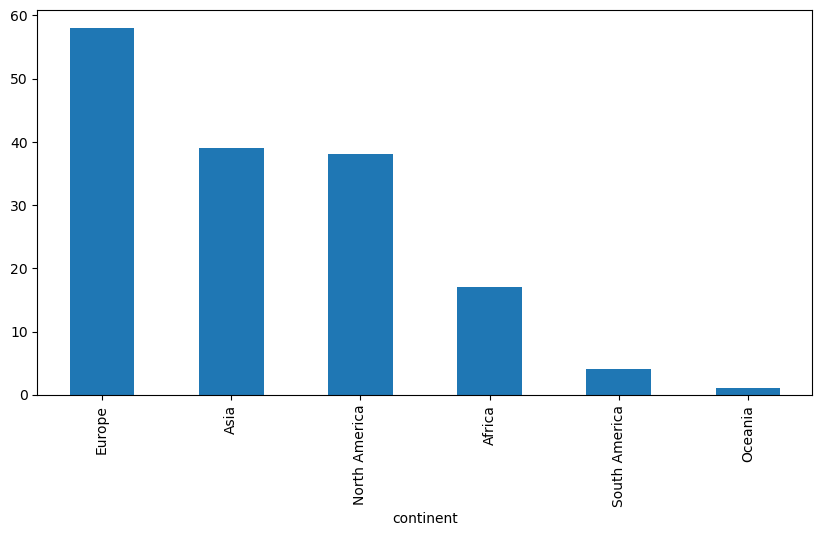

In [29]:
# make barplot with pandas(in continent)
df_tall_people['continent'].value_counts().plot(kind='bar', figsize=(10,5))

In [30]:
# Checked for which medical condition do most tall people have 
df_tall_people['medical_condition'].value_counts()

medical_condition
Gigantism     81
Genetic       47
Acromegaly    29
Name: count, dtype: int64